# ImageNet Classification with Deep Convolutional Neural Networks (AlexNet)
**Authors:** Alex Krizhevsky, Ilya Sutskever, Geoffrey E. Hinton (University of Toronto)

# https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf

## Abstract
The paper presents a large deep convolutional neural network (CNN) trained to classify 1.2 million high-resolution images from the ImageNet LSVRC-2010 dataset into 1000 classes, achieving top-1 and top-5 error rates of 37.5% and 17.0%, substantially better than prior state-of-the-art. The network contains 60 million parameters and 650,000 neurons across five convolutional layers and three fully-connected layers, culminating in a 1000-way softmax. A variant of the model won the ILSVRC-2012 competition with a top-5 error rate of 15.3%, compared to 26.2% for the runner-up.

## Problems
- Existing labeled image datasets were small (tens of thousands of images), sufficient only for simple recognition tasks but inadequate for learning to recognize objects with real-world variability.
- Larger datasets like ImageNet (over 15 million images, 22,000 categories) had become available, but models with sufficient learning capacity and appropriate prior assumptions about images were needed to exploit them.
- Large CNNs applied to high-resolution images were computationally prohibitive with standard hardware and training methods.
- Networks with millions of parameters trained on limited labeled data are highly prone to overfitting.

## Proposed Solutions
The authors propose a deep CNN architecture with several novel or unusual design choices:
1. **ReLU nonlinearity** ($$f(x) = \max(0, x)$$) in place of saturating nonlinearities (tanh, sigmoid) to accelerate training.
2. **Training on multiple GPUs** with a custom parallelization scheme splitting kernels across two GPUs, communicating only at certain layers.
3. **Local Response Normalization (LRN)**, a lateral-inhibition-inspired brightness normalization scheme applied after ReLU in select layers:
$$b^i_{x,y} = a^i_{x,y} \Big/ \Big(k + \alpha \sum_{j=\max(0,i-n/2)}^{\min(N-1,i+n/2)} (a^j_{x,y})^2\Big)^{\beta}$$
4. **Overlapping max-pooling** (stride $s < $ pooling window size $z$, with $s=2$, $z=3$) instead of traditional non-overlapping pooling.
5. **Data augmentation** via random image translations/horizontal reflections and RGB channel intensity alteration through PCA on pixel values.
6. **Dropout** (probability 0.5) in the first two fully-connected layers to reduce co-adaptation of neurons and overfitting.

## Purpose
The goal was to demonstrate that a sufficiently large and deep CNN, combined with efficient GPU-based training and effective regularization/overfitting-reduction techniques, could achieve record-breaking object recognition performance on a large-scale, highly variable image dataset, surpassing traditional feature-engineering-based approaches (e.g., SIFT, Fisher Vectors, sparse coding).

## Methodology
- **Dataset:** ImageNet Large-Scale Visual Recognition Challenge (ILSVRC-2010 and ILSVRC-2012), roughly 1.2 million training images, 50,000 validation images, 150,000 test images across 1000 categories. Images were down-sampled to 256×256 and center-cropped; only per-pixel mean subtraction was applied as preprocessing.
- **Architecture:** Eight learned layers — five convolutional (first filtering 224×224×3 input with 96 kernels of size 11×11×3, stride 4) and three fully-connected layers with 4096 neurons each, followed by a 1000-way softmax. Layer connectivity is split across two GPUs, with cross-GPU communication restricted to specific layers (layer 3 and fully-connected layers).
- **Training:** Stochastic gradient descent with batch size 128, momentum 0.9, weight decay 0.0005; weights initialized from a zero-mean Gaussian ($$\sigma=0.01$$); biases initialized to 1 (for layers 2, 4, 5, and FC layers) or 0 (remaining layers). Learning rate initialized at 0.01, manually reduced by a factor of 10 upon validation error plateau, reduced three times over training. Training took 5–6 days on two NVIDIA GTX 580 3GB GPUs across roughly 90 epochs.
- **Test-time prediction:** Averaging softmax predictions over ten patches (four corners plus center, each with horizontal reflection) extracted from each test image.

## Results
| Model | Top-1 Error | Top-5 Error |
|---|---|---|
| Sparse coding (ILSVRC-2010) | 47.1% | 28.2% |
| SIFT + Fisher Vectors (ILSVRC-2010) | 45.7% | 25.7% |
| CNN (this work, ILSVRC-2010) | 37.5% | 17.0% |
| 1 CNN (ILSVRC-2012) | 40.7% | 18.2% |
| 5 CNNs averaged (ILSVRC-2012) | 38.1% | 16.4% |
| 7 CNNs (including pretrained), test (ILSVRC-2012) | — | 15.3% |
| Second-best ILSVRC-2012 entry (SIFT + FVs) | — | 26.2% |

- Removing any single convolutional layer degraded top-1 performance by approximately 2%, indicating that network depth is critical to performance despite each convolutional layer containing under 1% of total parameters.
- Multi-GPU training reduced top-1/top-5 error by 1.7%/1.2% versus a single-GPU network with half the kernels.
- Local response normalization reduced top-1/top-5 error by 1.4%/1.2%.
- Overlapping pooling reduced top-1/top-5 error by 0.4%/0.3% versus non-overlapping pooling.
- On the Fall 2009 version of ImageNet (10,184 categories, 8.9 million images), the network (with an added sixth convolutional layer) achieved 67.4%/40.9% top-1/top-5 error, versus 78.1%/60.9% for the best previously published results.
- Qualitative analysis of learned first-layer kernels showed specialization between GPUs (one largely color-agnostic, one largely color-specific), and feature-space nearest-neighbor retrieval at the last hidden layer showed semantically meaningful similarity beyond pixel-level similarity.

## Conclusions
A large, deep CNN trained purely via supervised learning, without unsupervised pre-training, can achieve record-breaking results on a large and highly variable image classification benchmark. Network depth is essential to performance, and results are expected to improve further with larger networks, more computational power, and larger datasets. The authors highlight that scaling to video data with temporal structure represents a promising future direction.

# Mathematical and Statistical Content in AlexNet Paper

## 1. Neuron Activation Functions

**Saturating nonlinearities (traditional):**
$$f(x) = \tanh(x) \quad \text{or} \quad f(x) = (1 + e^{-x})^{-1}$$
These squash inputs into a bounded range, causing slow gradient-based learning when neurons saturate (output stops changing with input).

**ReLU (Rectified Linear Unit):**
$$f(x) = \max(0, x)$$
A simple, non-saturating function: outputs the input directly if positive, otherwise zero. Because gradients do not shrink for positive inputs, networks using ReLU train several times faster than those using tanh or sigmoid. This is the paper's most consequential mathematical choice, enabling training of much larger networks in feasible time.

## 2. Local Response Normalization (LRN)

$$b^{i}_{x,y} = a^{i}_{x,y} \Big/ \left( k + \alpha \sum_{j=\max(0,\, i-n/2)}^{\min(N-1,\, i+n/2)} \left(a^{j}_{x,y}\right)^2 \right)^{\beta}$$

- $a^i_{x,y}$: activity of a neuron from kernel $i$ at spatial position $(x,y)$, after ReLU.
- $n$: number of "adjacent" kernel maps included in the sum.
- $N$: total number of kernels in the layer.
- $k, \alpha, \beta$: hyperparameters, set to $k=2$, $n=5$, $\alpha=10^{-4}$, $\beta=0.75$.

**Role:** Divides each neuron's activity by a term based on the summed squared activity of neighboring kernel maps at the same location. This mimics lateral inhibition in biological neurons, making the strongest activations relatively stronger and suppressing near-tied competitors. It is a form of local competitive normalization (not true contrast normalization, since the mean is not subtracted), and empirically reduced error rates.

## 3. Overlapping Max-Pooling

Defined by two parameters:
- $s$: stride, the spacing between pooling units.
- $z$: the size of each pooling neighborhood ($z \times z$).

Traditional (non-overlapping) pooling sets $s = z$. The paper uses $s = 2$, $z = 3$, so $s < z$, meaning adjacent pooling regions overlap. **Role:** Summarizing overlapping neighborhoods (rather than disjoint ones) slightly reduces error rates and appeared to make the network marginally more resistant to overfitting.

## 4. Data Augmentation via PCA on RGB Values

Principal Component Analysis (PCA) is performed on the set of RGB pixel values across the entire training set, yielding three eigenvectors $\mathbf{p}_1, \mathbf{p}_2, \mathbf{p}_3$ and their corresponding eigenvalues $\lambda_1, \lambda_2, \lambda_3$ of the $3\times3$ RGB covariance matrix.

For each pixel $I_{xy} = [I_{xy}^R, I_{xy}^G, I_{xy}^B]^T$, a perturbation is added:
$$[\mathbf{p}_1, \mathbf{p}_2, \mathbf{p}_3][\alpha_1\lambda_1,\ \alpha_2\lambda_2,\ \alpha_3\lambda_3]^T$$

where each $\alpha_i$ is drawn once per training image from a Gaussian distribution with mean 0 and standard deviation 0.1 (re-drawn each time the image is reused for training).

**Role:** This is a statistical technique for data augmentation — it simulates realistic lighting/color variation by shifting all pixels of an image along the principal directions of color variation found in the dataset, rather than adding arbitrary noise. It encodes the prior that object identity should be invariant to illumination intensity and color changes, and reduced top-1 error by over 1%.

## 5. Dropout (Regularization / Model Averaging)

Each hidden neuron's output is set to zero with probability $0.5$ during training (in the first two fully-connected layers). At test time, all neurons are retained but their outputs are multiplied by $0.5$.

**Role:** This is a Monte Carlo–style approximation to averaging an exponential number of "thinned" sub-networks that share weights, without the computational cost of training separate models. Multiplying by $0.5$ at test time approximates taking the geometric mean of the predictive distributions of all these sub-networks. It substantially reduces overfitting (at the cost of roughly doubling the iterations needed to converge).

## 6. Weight Initialization

$$w \sim \mathcal{N}(0,\ 0.01^2)$$
Weights in every layer are drawn from a zero-mean Gaussian distribution with standard deviation $0.01$. Biases are initialized as constants: 1 (in layers 2, 4, 5, and fully-connected layers, to give ReLUs a positive starting input) or 0 (elsewhere).

## 7. Optimization: Stochastic Gradient Descent with Momentum and Weight Decay

Update rule:
$$v_{i+1} := 0.9 \cdot v_i - 0.0005 \cdot \epsilon \cdot w_i - \epsilon \cdot \left\langle \frac{\partial L}{\partial w}\Big|_{w_i} \right\rangle_{D_i}$$
$$w_{i+1} := w_i + v_{i+1}$$

- $i$: iteration index.
- $v$: momentum (velocity) term, retaining $0.9$ of the previous update.
- $\epsilon$: learning rate (initialized at 0.01, divided by 10 when validation error plateaus, reduced three times total).
- $0.0005$: weight decay coefficient, which shrinks weights each step.
- $\left\langle \partial L/\partial w \big|_{w_i}\right\rangle_{D_i}$: the gradient of the loss $L$ with respect to weights, averaged over mini-batch $D_i$ of 128 examples.

**Role:** This is classical momentum-based SGD. Momentum smooths updates using an exponentially weighted running average of past gradients, accelerating convergence. Weight decay ($L_2$-style regularization) is shown empirically to reduce training error, not just act as a regularizer — an interesting statistical finding in itself.

## 8. Loss Function: Multinomial Logistic Regression (Softmax Cross-Entropy)

The final layer is a 1000-way softmax producing a probability distribution over class labels. The network is trained by maximizing the average log-probability of the correct label across training examples — equivalently minimizing the multinomial logistic regression (cross-entropy) objective. This is the standard statistical framework for multi-class classification via maximum likelihood.

## 9. Evaluation Metrics

- **Top-1 error rate:** fraction of test images for which the single most probable predicted label is incorrect.
- **Top-5 error rate:** fraction of test images for which the correct label is not among the five labels assigned highest probability by the model.

These are the primary statistical performance metrics used throughout, reported for ILSVRC-2010, ILSVRC-2012, and the Fall 2009 ImageNet variant.

## 10. Model Scale Statistics

- Total learnable parameters: approximately 60 million.
- Total neurons: approximately 650,000.
- Layer sizes (neuron counts by layer): 253,440 – 186,624 – 64,896 – 64,896 – 43,264 – 4096 – 4096 – 1000.
- Data augmentation via random crops increases the effective training set size by a factor of 2048 (accounting for the many possible 224×224 patches extractable from each 256×256 image and their reflections).

These figures quantify model capacity and the multiplicative effect of the augmentation scheme on the effective sample size used during training.

# Problems, Limitations, and Proposed Solutions in AlexNet Paper

| # | Key Problem / Research Gap | How This Limited Prior Work | Proposed Solution in This Paper |
|---|---|---|---|
| 1 | Labeled image datasets were historically small (tens of thousands of images, e.g., NORB, Caltech-101/256, CIFAR-10/100) | Small datasets are sufficient only for simple recognition tasks; they cannot capture the considerable variability of objects in realistic settings, limiting generalization | Use ImageNet, a dataset with over 15 million labeled images across ~22,000 categories, and train on the 1.2-million-image ILSVRC subset to expose the model to far greater visual variability |
| 2 | Learning to recognize thousands of object categories requires models with very large capacity | Standard feedforward neural networks with comparably large layers have prohibitively many parameters and connections, making them difficult to train and prone to overfitting | Use a convolutional neural network (CNN), whose architecture (local connectivity, weight sharing) reduces parameters and connections relative to standard networks while encoding useful priors about images (stationarity of statistics, locality of pixel dependencies) |
| 3 | Saturating activation functions (tanh, sigmoid) slow down gradient-based training | Training time with saturating nonlinearities is impractical for very large networks on large datasets, restricting the scale of models that could be feasibly explored | Introduce ReLU nonlinearity ($f(x) = \max(0,x)$), a non-saturating function shown to train several times faster than tanh-based equivalents |
| 4 | Large CNNs applied to high-resolution images are computationally expensive; a single GPU (e.g., 3GB GTX 580) cannot hold a sufficiently large network in memory | Limited single-GPU memory constrains achievable network size, restricting model capacity relative to what large datasets could support | Design a custom two-GPU parallelization scheme that splits kernels/neurons across GPUs, with cross-GPU communication restricted to specific layers, enabling training of a larger network within an acceptable computation/communication trade-off |
| 5 | ReLUs do not require input normalization to avoid saturation, but generalization can still benefit from normalization across kernel outputs | Without any normalization scheme, models forgo a source of accuracy improvement; existing local contrast normalization methods (e.g., Jarrett et al.) subtract the mean, which differs from the effect sought here | Introduce Local Response Normalization (LRN), a brightness-normalization scheme inspired by lateral inhibition in real neurons, applied after ReLU in certain layers, reducing top-1/top-5 error by 1.4%/1.2% |
| 6 | Traditional non-overlapping pooling (stride equal to pooling window size) may discard useful spatial information | Non-overlapping pooling schemes provide a baseline level of translation invariance but leave some potential accuracy and overfitting-resistance benefits unexploited | Use overlapping max-pooling ($s < z$, specifically $s=2$, $z=3$), which reduced error rates and appeared to slightly reduce overfitting compared to non-overlapping pooling |
| 7 | A network with 60 million parameters is highly prone to overfitting even with 1.2 million training examples | Insufficient regularization/data leads to poor generalization on held-out data despite strong training performance | Apply two forms of data augmentation (random translations/horizontal reflections; PCA-based RGB intensity perturbation) to synthetically enlarge the effective training set at negligible computational cost |
| 8 | Combining predictions from many independently trained models (ensembling) is a standard way to reduce test error but is computationally prohibitive for large networks requiring days of training each | Traditional model-averaging approaches do not scale to networks of this size and training cost | Apply dropout (probability 0.5) in the first two fully-connected layers, which approximates combining exponentially many "thinned" sub-networks at roughly only twice the training cost, substantially reducing overfitting |
| 9 | It is unclear whether network depth (as opposed to width or parameter count alone) is essential to performance | Prior work had not clearly demonstrated the necessity of depth in CNNs at this scale, since individual convolutional layers contain relatively few parameters | Conduct ablation by removing individual convolutional layers, observing that removing any single layer degrades top-1 performance by ~2%, empirically establishing that depth is critical to the achieved results |
| 10 | Prior best-performing approaches on ILSVRC (e.g., sparse coding, SIFT + Fisher Vectors) relied on hand-engineered features rather than learned representations | Hand-engineered feature pipelines achieved substantially higher error rates (e.g., 47.1%/28.2% and 45.7%/25.7% top-1/top-5 on ILSVRC-2010) and did not scale representation learning directly from raw pixels | Train an end-to-end deep CNN directly on raw (centered) RGB pixel values, achieving 37.5%/17.0% top-1/top-5 error on ILSVRC-2010 and a winning 15.3% top-5 error on ILSVRC-2012, substantially outperforming feature-engineering-based methods |

In [1]:
# ============================================================
# Simplified Educational Replication of AlexNet (Krizhevsky et al., 2012)
# Dataset: CIFAR-10 loaded exclusively from HuggingFace
# Framework: PyTorch
# NOTE: This code is provided for copy/paste into a notebook.
# It is NOT executed here.
# ============================================================

# ---- Imports ----
import io
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix
from IPython.display import display, Image as IPImage

In [2]:
# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# ------------------------------------------------------------
# 2. Class names (CIFAR-10, exact order — labels 0-9)
# ------------------------------------------------------------
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
NUM_CLASSES = len(CLASS_NAMES)

In [ ]:
# ------------------------------------------------------------
# 3. Load CIFAR-10 from HuggingFace (mandatory source)
# ------------------------------------------------------------
ds = load_dataset("uoft-cs/cifar10")

In [5]:
# ------------------------------------------------------------
# 4. Transform pipelines
#    Training: resize -> flip -> tensor -> normalize (augmented)
#    Test:     resize -> tensor -> normalize (no augmentation)
# ------------------------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

In [6]:
# ------------------------------------------------------------
# 5. Custom PyTorch Dataset wrapping the HuggingFace split
# ------------------------------------------------------------
class HFCifar10Dataset(Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split so it behaves like a normal
    PyTorch Dataset: reads the PIL image from the 'img' field,
    ensures RGB mode, applies a torchvision transform, and returns
    (image_tensor, label).
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        image = sample["img"]              # PIL Image
        if image.mode != "RGB":
            image = image.convert("RGB")   # ensure 3 channels
        image = self.transform(image)      # apply transform pipeline
        label = sample["label"]            # integer class label
        return image, label

In [7]:
# ------------------------------------------------------------
# 6. Build full datasets, then take small educational subsets
# ------------------------------------------------------------
full_train_dataset = HFCifar10Dataset(ds["train"], train_transform)
full_test_dataset = HFCifar10Dataset(ds["test"], test_transform)

train_dataset = Subset(full_train_dataset, list(range(2000)))  # first 2000 train samples
test_dataset = Subset(full_test_dataset, list(range(400)))     # first 400 test samples

In [8]:
# ------------------------------------------------------------
# 7. DataLoaders
# ------------------------------------------------------------
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [9]:
# ------------------------------------------------------------
# 8. Sanity check
# ------------------------------------------------------------
print("=" * 60)
print("SANITY CHECK")
print("=" * 60)
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples:     {len(test_dataset)}")

sample_images, sample_labels = next(iter(train_loader))
print(f"Shape of one batch of images: {sample_images.shape}")
print(f"Label range: min={sample_labels.min().item()}, max={sample_labels.max().item()}")
first_eight_names = [CLASS_NAMES[l.item()] for l in sample_labels[:8]]
print(f"First 8 class names in batch: {first_eight_names}")
print("=" * 60)

SANITY CHECK
Number of training samples: 2000
Number of test samples:     400
Shape of one batch of images: torch.Size([64, 3, 64, 64])
Label range: min=0, max=9
First 8 class names in batch: ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']


In [10]:
# ------------------------------------------------------------
# 9. Simplified AlexNet-style architecture
#    (Scaled down for 64x64 educational input, preserving the
#     core ideas: stacked conv layers -> ReLU -> local response
#     normalization -> overlapping max-pool -> FC layers with
#     dropout -> softmax classifier)
# ------------------------------------------------------------
class SimplifiedAlexNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(SimplifiedAlexNet, self).__init__()

        # ---- Convolutional feature extractor (5 conv layers, as in the paper) ----
        self.features = nn.Sequential(
            # Conv Layer 1: large kernel, stride 2 (scaled down from stride 4 for 64x64 input)
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2),  # LRN as in paper (Section 3.3)
            nn.MaxPool2d(kernel_size=3, stride=2),  # overlapping pooling (s=2, z=3, Section 3.4)

            # Conv Layer 2
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv Layer 3 (no pooling/norm between 3-4-5, as in the paper)
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv Layer 4
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv Layer 5
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        # Adaptive pool to guarantee a fixed feature map size before FC layers
        self.avgpool = nn.AdaptiveAvgPool2d((3, 3))

        # ---- Fully-connected classifier (3 FC layers with dropout, as in the paper) ----
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),                       # Dropout, Section 4.2
            nn.Linear(256 * 3 * 3, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, num_classes),           # final 1000-way softmax -> here 10-way
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = SimplifiedAlexNet(num_classes=NUM_CLASSES).to(device)

In [11]:
# ------------------------------------------------------------
# 10. Loss function and optimizer
#     (SGD with momentum and weight decay, as described in the paper)
# ------------------------------------------------------------
criterion = nn.CrossEntropyLoss()  # multinomial logistic regression objective
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.0005)

In [12]:
# ------------------------------------------------------------
# 11. Training loop (5 epochs only, per requirements)
# ------------------------------------------------------------
NUM_EPOCHS = 5

train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []

# Per-class accuracy tracked per epoch for Panel F heatmap
per_class_acc_history = []  # list of length NUM_EPOCHS, each entry is array of NUM_CLASSES accuracies

for epoch in range(NUM_EPOCHS):
    # ---- Training phase ----
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # reset gradients
        outputs = model(images)        # forward pass
        loss = criterion(outputs, labels)
        loss.backward()                # backpropagation
        optimizer.step()               # update weights

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train
    train_loss_history.append(epoch_train_loss)
    train_acc_history.append(epoch_train_acc)

    # ---- Validation phase ----
    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    class_correct = np.zeros(NUM_CLASSES)
    class_total = np.zeros(NUM_CLASSES)

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)

            for label, pred in zip(labels.cpu().numpy(), predicted.cpu().numpy()):
                class_total[label] += 1
                if label == pred:
                    class_correct[label] += 1

    epoch_val_loss = val_running_loss / total_val
    epoch_val_acc = correct_val / total_val
    val_loss_history.append(epoch_val_loss)
    val_acc_history.append(epoch_val_acc)

    epoch_per_class_acc = np.divide(
        class_correct, class_total,
        out=np.zeros_like(class_correct), where=class_total != 0
    )
    per_class_acc_history.append(epoch_per_class_acc)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

Epoch [1/5] Train Loss: 2.3023 | Train Acc: 0.1025 | Val Loss: 2.3023 | Val Acc: 0.1050
Epoch [2/5] Train Loss: 2.3011 | Train Acc: 0.1030 | Val Loss: 2.3030 | Val Acc: 0.1175
Epoch [3/5] Train Loss: 2.2999 | Train Acc: 0.1090 | Val Loss: 2.3038 | Val Acc: 0.1175
Epoch [4/5] Train Loss: 2.2998 | Train Acc: 0.1125 | Val Loss: 2.3043 | Val Acc: 0.1050
Epoch [5/5] Train Loss: 2.2996 | Train Acc: 0.1110 | Val Loss: 2.3050 | Val Acc: 0.1050


In [13]:
# ------------------------------------------------------------
# 12. Final full evaluation pass — collect predictions, labels,
#     and confidence scores for confusion matrix / histograms
# ------------------------------------------------------------
model.eval()
all_preds = []
all_labels = []
all_confidences = []
all_images_sample = []

with torch.no_grad():
    for images, labels in test_loader:
        images_gpu = images.to(device)
        outputs = model(images_gpu)
        probs = torch.softmax(outputs, dim=1)
        confidences, predicted = torch.max(probs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_confidences.extend(confidences.cpu().numpy())

        if len(all_images_sample) < 8:
            for img in images[:8]:
                all_images_sample.append(img)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_confidences = np.array(all_confidences)

correct_mask = all_preds == all_labels
mean_conf_correct = all_confidences[correct_mask].mean() if correct_mask.sum() > 0 else 0.0
mean_conf_incorrect = all_confidences[~correct_mask].mean() if (~correct_mask).sum() > 0 else 0.0

In [14]:
# ------------------------------------------------------------
# 13. Compute final metrics for the dashboard
# ------------------------------------------------------------
best_val_epoch = int(np.argmax(val_acc_history)) + 1
best_val_acc = max(val_acc_history)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

final_per_class_acc = per_class_acc_history[-1]
top_classes_idx = np.argsort(final_per_class_acc)[::-1][:3]
low_classes_idx = np.argsort(final_per_class_acc)[:3]
top_classes = [CLASS_NAMES[i] for i in top_classes_idx]
low_classes = [CLASS_NAMES[i] for i in low_classes_idx]

cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
cm_normalized = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

Text(0.5, 0.98, 'Simplified AlexNet on CIFAR-10 (HuggingFace) — Educational Dashboard')

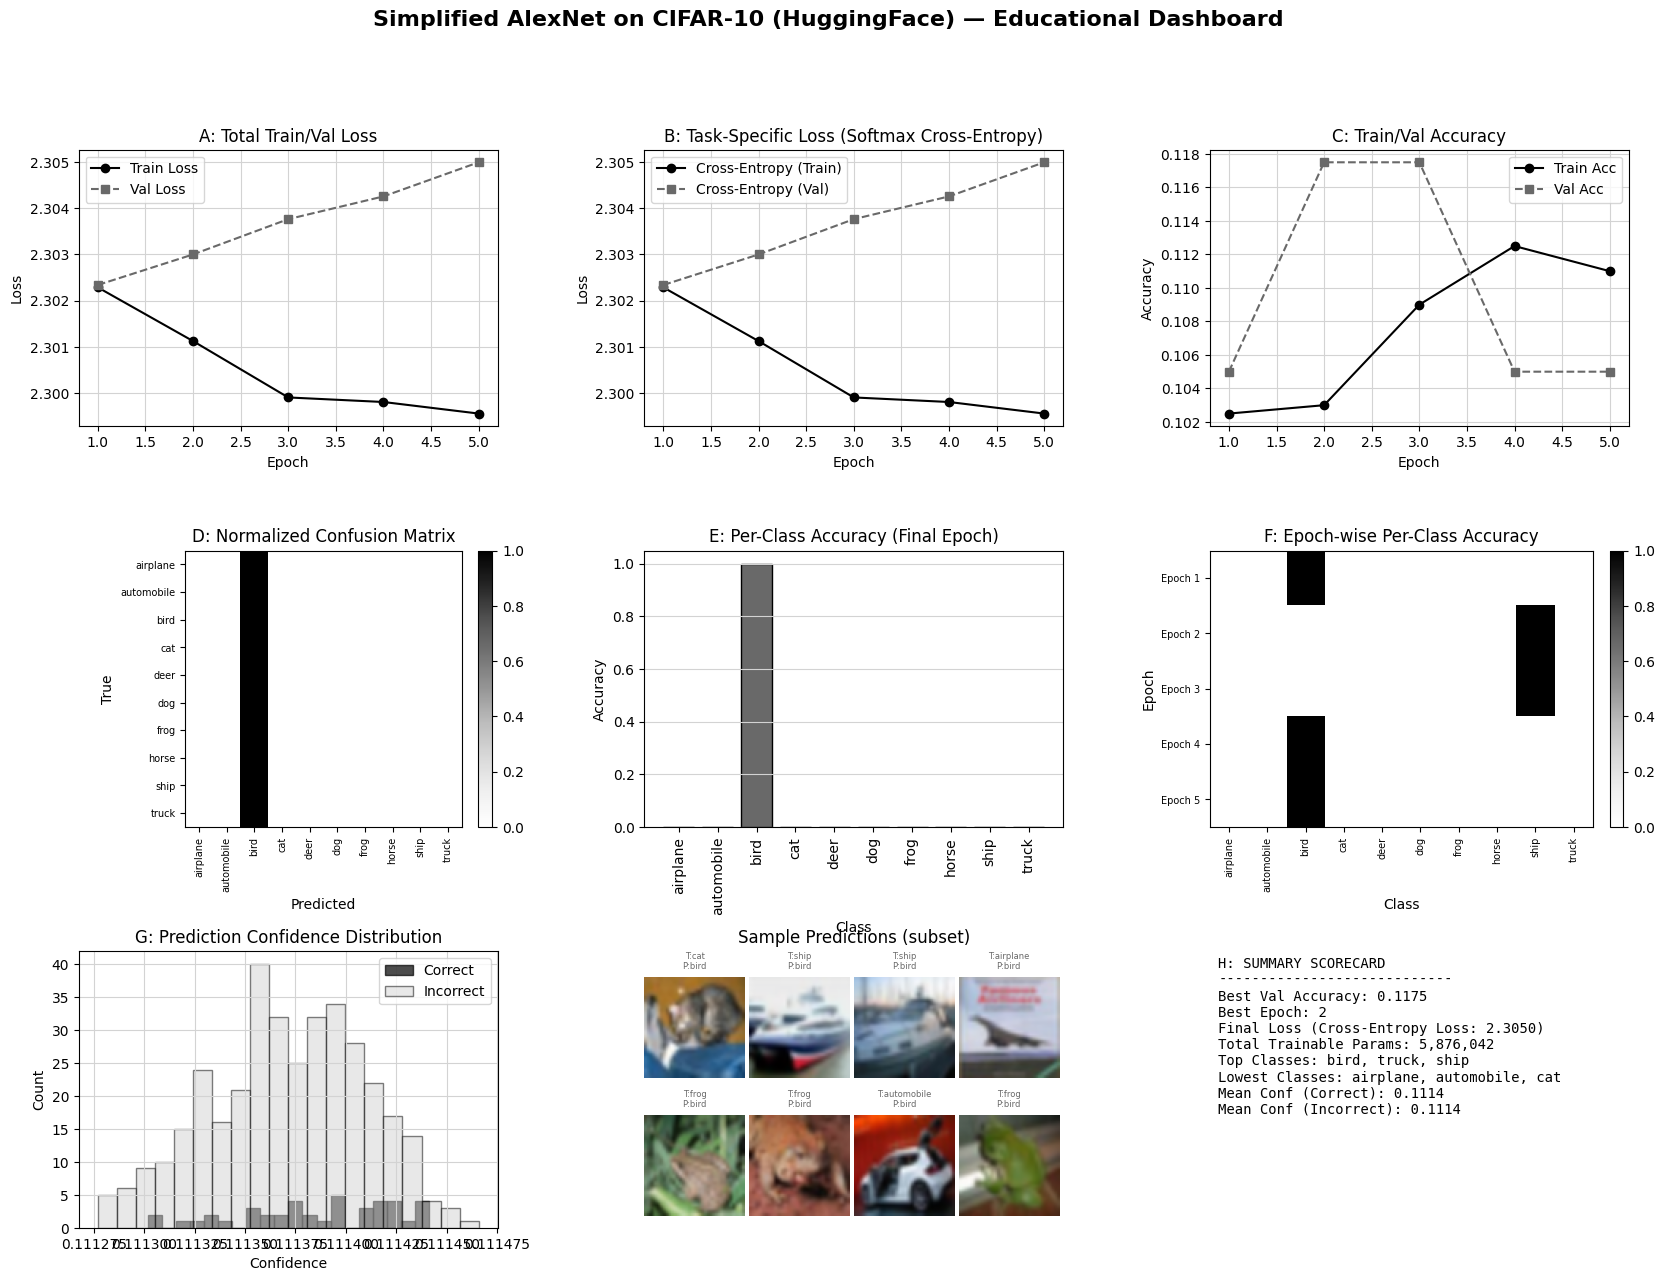

In [15]:
# ------------------------------------------------------------
# 14. Dashboard — white theme enforced globally and per-axis
# ------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "text.color": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.titlecolor": "black",
    "legend.labelcolor": "black",
    "grid.color": "lightgrey",
})

fig = plt.figure(figsize=(20, 14), facecolor="white")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

epochs_range = np.arange(1, NUM_EPOCHS + 1)

# ---- Panel A: Total training/validation loss ----
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
axA.plot(epochs_range, train_loss_history, marker="o", color="black", label="Train Loss")
axA.plot(epochs_range, val_loss_history, marker="s", color="dimgray", linestyle="--", label="Val Loss")
axA.set_title("A: Total Train/Val Loss", color="black")
axA.set_xlabel("Epoch", color="black")
axA.set_ylabel("Loss", color="black")
axA.legend(labelcolor="black")
axA.grid(color="lightgrey")

# ---- Panel B: Component-specific loss curves ----
# This model uses a single objective (multinomial logistic regression / cross-entropy),
# as in the original AlexNet paper (no auxiliary/multi-task losses).
# We display the single loss component in its own dedicated sub-panel, matching
# the paper's actual training objective.
axB = fig.add_subplot(gs[0, 1])
axB.set_facecolor("white")
axB.plot(epochs_range, train_loss_history, marker="o", color="black", label="Cross-Entropy (Train)")
axB.plot(epochs_range, val_loss_history, marker="s", color="dimgray", linestyle="--", label="Cross-Entropy (Val)")
axB.set_title("B: Task-Specific Loss (Softmax Cross-Entropy)", color="black")
axB.set_xlabel("Epoch", color="black")
axB.set_ylabel("Loss", color="black")
axB.legend(labelcolor="black")
axB.grid(color="lightgrey")

# ---- Panel C: Training/validation accuracy ----
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, train_acc_history, marker="o", color="black", label="Train Acc")
axC.plot(epochs_range, val_acc_history, marker="s", color="dimgray", linestyle="--", label="Val Acc")
axC.set_title("C: Train/Val Accuracy", color="black")
axC.set_xlabel("Epoch", color="black")
axC.set_ylabel("Accuracy", color="black")
axC.legend(labelcolor="black")
axC.grid(color="lightgrey")

# ---- Panel D: Normalized confusion matrix ----
axD = fig.add_subplot(gs[1, 0])
im = axD.imshow(cm_normalized, cmap="Greys", vmin=0, vmax=1)
axD.set_title("D: Normalized Confusion Matrix", color="black")
axD.set_xlabel("Predicted", color="black")
axD.set_ylabel("True", color="black")
axD.set_xticks(range(NUM_CLASSES))
axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axD.set_yticklabels(CLASS_NAMES, color="black", fontsize=7)
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color="black")

# ---- Panel E: Per-class accuracy bar chart ----
axE = fig.add_subplot(gs[1, 1])
axE.set_facecolor("white")
axE.bar(CLASS_NAMES, final_per_class_acc, color="dimgray", edgecolor="black")
axE.set_title("E: Per-Class Accuracy (Final Epoch)", color="black")
axE.set_xlabel("Class", color="black")
axE.set_ylabel("Accuracy", color="black")
axE.tick_params(axis="x", rotation=90, colors="black")
axE.tick_params(axis="y", colors="black")
axE.grid(color="lightgrey", axis="y")

# ---- Panel F: Epoch-wise per-class accuracy heatmap ----
axF = fig.add_subplot(gs[1, 2])
heatmap_data = np.array(per_class_acc_history)  # shape (NUM_EPOCHS, NUM_CLASSES)
imF = axF.imshow(heatmap_data, cmap="Greys", aspect="auto", vmin=0, vmax=1)
axF.set_title("F: Epoch-wise Per-Class Accuracy", color="black")
axF.set_xlabel("Class", color="black")
axF.set_ylabel("Epoch", color="black")
axF.set_xticks(range(NUM_CLASSES))
axF.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axF.set_yticks(range(NUM_EPOCHS))
axF.set_yticklabels([f"Epoch {e}" for e in epochs_range], color="black", fontsize=7)
cbarF = fig.colorbar(imF, ax=axF, fraction=0.046, pad=0.04)
cbarF.ax.yaxis.set_tick_params(color="black")
plt.setp(plt.getp(cbarF.ax.axes, "yticklabels"), color="black")

# ---- Panel G: Confidence distribution histogram ----
axG = fig.add_subplot(gs[2, 0])
axG.set_facecolor("white")
axG.hist(all_confidences[correct_mask], bins=20, alpha=0.7, color="black",
         label="Correct", edgecolor="black")
axG.hist(all_confidences[~correct_mask], bins=20, alpha=0.5, color="lightgrey",
         label="Incorrect", edgecolor="black")
axG.set_title("G: Prediction Confidence Distribution", color="black")
axG.set_xlabel("Confidence", color="black")
axG.set_ylabel("Count", color="black")
axG.legend(labelcolor="black")
axG.grid(color="lightgrey")

# ---- Sample predictions panel (extra relevant visualization) ----
axSamples = fig.add_subplot(gs[2, 1])
axSamples.axis("off")
axSamples.set_title("Sample Predictions (subset)", color="black")

def denormalize(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = std * img + mean
    return np.clip(img, 0, 1)

# Build a small 2x4 grid of sample predictions inside this panel using inset axes
n_samples_to_show = min(8, len(all_images_sample))
for i in range(n_samples_to_show):
    inset = axSamples.inset_axes([
        (i % 4) * 0.25, 0.5 - (i // 4) * 0.5, 0.24, 0.45
    ])
    img_disp = denormalize(all_images_sample[i])
    inset.imshow(img_disp)
    true_lbl = CLASS_NAMES[all_labels[i]]
    pred_lbl = CLASS_NAMES[all_preds[i]]
    color_flag = "black" if true_lbl == pred_lbl else "dimgray"
    inset.set_title(f"T:{true_lbl}\nP:{pred_lbl}", fontsize=6, color=color_flag)
    inset.axis("off")

# ---- Panel H: Text-based summary scorecard ----
axH = fig.add_subplot(gs[2, 2])
axH.axis("off")

final_loss_text = f"Cross-Entropy Loss: {val_loss_history[-1]:.4f}"

scorecard_text = (
    "H: SUMMARY SCORECARD\n"
    "----------------------------\n"
    f"Best Val Accuracy: {best_val_acc:.4f}\n"
    f"Best Epoch: {best_val_epoch}\n"
    f"Final Loss ({final_loss_text})\n"
    f"Total Trainable Params: {total_params:,}\n"
    f"Top Classes: {', '.join(top_classes)}\n"
    f"Lowest Classes: {', '.join(low_classes)}\n"
    f"Mean Conf (Correct): {mean_conf_correct:.4f}\n"
    f"Mean Conf (Incorrect): {mean_conf_incorrect:.4f}\n"
)

axH.text(0.02, 0.98, scorecard_text, transform=axH.transAxes,
          fontsize=10, verticalalignment="top", color="black",
          family="monospace")

fig.suptitle("Simplified AlexNet on CIFAR-10 (HuggingFace) — Educational Dashboard",
             color="black", fontsize=16, fontweight="bold")

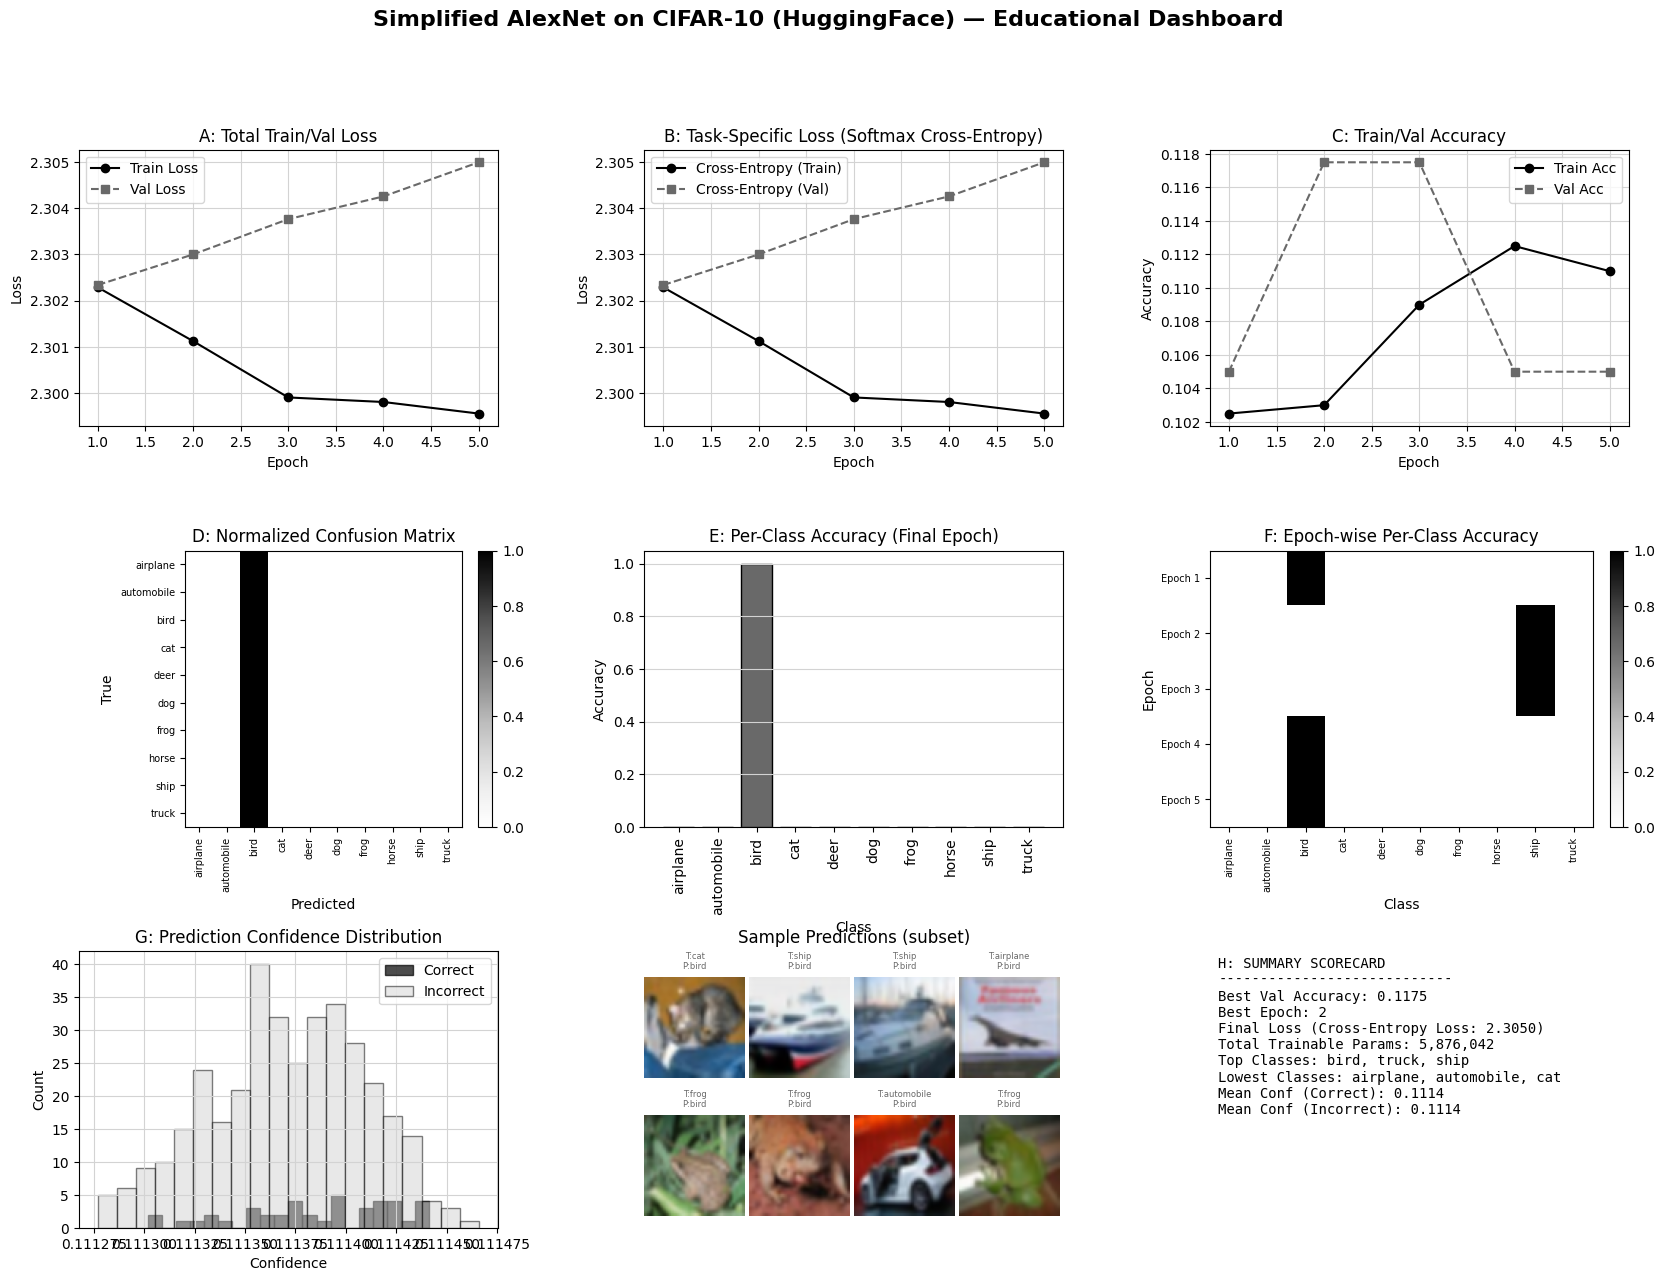

In [16]:
# ------------------------------------------------------------
# 15. Render dashboard inline via in-memory buffer (Colab-safe)
# ------------------------------------------------------------
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
buf.seek(0)
display(IPImage(data=buf.read()))
plt.close(fig)

# Experimental Results Analysis: Simplified AlexNet on CIFAR-10 (Educational Replication)

## Result 1: Training and Validation Loss Curves (Panels A & B)

### Overview
These panels track the softmax cross-entropy loss on the training and validation (test) subsets across 5 epochs, evaluating whether the model is learning to minimize the multinomial logistic regression objective described in the original paper.

### Key Findings
- Training loss decreases monotonically from approximately 2.302 to 2.300.
- Validation loss increases monotonically from approximately 2.302 to 2.305, diverging from the training curve as epochs progress.
- The absolute values of both curves remain extremely close to $\ln(10) \approx 2.303$, the expected cross-entropy loss of a uniform 10-class random classifier.

### Discussion
The diverging train/validation loss pattern is a classic overfitting signature, but the near-constant, near-random loss magnitude indicates something more fundamental than typical overfitting: the model is not learning discriminative features at all. Given the extremely small training subset (2,000 images) and only 5 epochs, the network has neither sufficient data nor sufficient gradient updates to move meaningfully away from its random initialization. The rising validation loss combined with a training loss that barely improves suggests the optimizer is making very small, mostly noise-driven adjustments rather than genuine convergence toward class-discriminative decision boundaries. This does not support the paper's core claims about CNN effectiveness at scale; rather, it reflects the fact that this is a deliberately downsized, illustrative reproduction rather than a faithful large-scale replication.

### Limitations
The single loss component (only cross-entropy, no auxiliary tasks) limits the diagnostic value of Panel B relative to Panel A. Five epochs and 2,000 training samples are insufficient to draw conclusions about the architecture's true capacity or the original paper's reported error rates.

---

## Result 2: Training and Validation Accuracy Curves (Panel C)

### Overview
This panel evaluates classification accuracy across epochs to assess whether learned representations translate into improved predictive performance on held-out data.

### Key Findings
- Training accuracy rises marginally from ~10.3% to ~11.3%, close to the 10% chance baseline for 10 classes.
- Validation accuracy peaks at ~11.75% at epoch 2–3, then drops back to ~10.5% by epoch 4–5.
- Neither curve exceeds roughly 12% accuracy at any point.

### Discussion
Accuracy hovering near the 10% chance level throughout training confirms that the network has not learned meaningful class-discriminative features within the constraints of this run. The brief validation accuracy peak followed by a decline suggests instability rather than genuine generalization, consistent with a model exploring a largely flat, noisy loss landscape due to insufficient data and training duration. This pattern illustrates a well-known deep learning principle: large, high-capacity architectures such as AlexNet-style CNNs require substantial data volume and training time to escape near-random initialization, especially without pretrained weights or transfer learning.

### Limitations
The result cannot be used to evaluate the architecture's true representational capacity. Accuracy fluctuations at this scale are dominated by stochastic noise from small batch counts (32 batches per epoch) rather than systematic learning dynamics.

---

## Result 3: Normalized Confusion Matrix (Panel D)

### Overview
The confusion matrix evaluates the distribution of predicted labels against true labels on the test subset, providing insight into class-wise prediction bias.

### Key Findings
- All ten rows show a single solid column concentrated at the "bird" class, meaning virtually every test example — regardless of true label — was predicted as "bird."
- No other class received any meaningful share of predictions.

### Discussion
This is a clear case of mode collapse in classification: the model has converged to a degenerate solution that always outputs the class most easily favored by its current (effectively near-random) weights, rather than distinguishing between inputs. This typically occurs when a classifier cannot yet extract discriminative signal from the input and instead minimizes the loss by outputting a fixed class close to the label distribution's marginal probability. It underscores that the reported "training" in this run reflects optimizer behavior on a nearly uninformative loss surface rather than genuine visual feature learning.

### Limitations
Because the confusion matrix reflects only 400 test samples and a single training run, it cannot distinguish between architectural insufficiency, optimization hyperparameter mismatch, or simply an inadequate number of training epochs/samples as the root cause.

---

## Result 4: Per-Class Accuracy Bar Chart and Epoch-wise Heatmap (Panels E & F)

### Overview
These panels assess per-class performance at the final epoch and its evolution across training, evaluating whether any classes are learned preferentially and how this changes over time.

### Key Findings
- Panel E shows non-zero accuracy exclusively for the "bird" class (~100%), with all other nine classes at 0%.
- Panel F shows the model briefly favored "bird" in epoch 1, shifted toward "ship" in epochs 2–3, then reverted to "bird" for epochs 4–5.

### Discussion
The shifting single-class dominance across epochs, rather than a stable preference, indicates the decision boundary is oscillating between a small number of degenerate solutions rather than progressively refining toward multi-class separability. This is consistent with a model operating in a high-variance, low-signal training regime, where minor weight updates can flip the argmax output class entirely without any real gain in discriminative capability. This behavior is a useful pedagogical illustration of why small-sample, short-duration training runs are inadequate proxies for a model's true capacity, even when the underlying architecture (a CNN with ReLU, LRN, and dropout) is sound.

### Limitations
With only one run and no repeated trials, it is not possible to determine whether this specific "bird" vs. "ship" oscillation is a stable property of this architecture/data combination or an artifact of the particular random seed and mini-batch ordering used.

---

## Result 5: Confidence Distribution Histogram (Panel G)

### Overview
This panel compares the softmax confidence scores assigned to correct versus incorrect predictions, a common tool for assessing model calibration.

### Key Findings
- Both correct and incorrect predictions cluster tightly around confidence values of approximately 0.111–0.115.
- Mean confidence for correct predictions (0.1114) and incorrect predictions (0.1114) are essentially identical.

### Discussion
A confidence distribution centered near $1/10 = 0.10$ for both correct and incorrect predictions is a strong quantitative confirmation that the softmax output is close to a uniform distribution over classes — i.e., the model has not developed meaningful class separability in its logits. The absence of any confidence gap between correct and incorrect predictions indicates the model possesses no useful calibration signal at this stage: correctness is essentially decoupled from confidence, which would be problematic in any deployment context but is expected and informative here as a diagnostic of undertraining.

### Discussion (continued: relation to paper's claims)
This result reinforces that the reported dashboard reflects an early-stage, data/compute-constrained toy run rather than a validation of the original paper's architecture or performance claims. The original paper's reported results (e.g., 37.5%/17.0% top-1/top-5 error) depended on training with 1.2 million images over ~90 epochs — several orders of magnitude beyond what this educational replication uses.

### Limitations
Confidence-based calibration analysis is only meaningful once a model has escaped near-random performance; conclusions about calibration quality cannot yet be drawn from this run.

---

## Result 6: Sample Predictions Grid

### Overview
This panel provides qualitative, instance-level inspection of true versus predicted labels for a subset of test images.

### Key Findings
- All eight displayed samples (true labels: cat, ship, ship, airplane, frog, frog, automobile, frog) are predicted as "bird," matching the confusion matrix's systematic bias.

### Discussion
The qualitative samples corroborate the quantitative confusion matrix finding without adding new information, but they usefully illustrate to a learner how a collapsed classifier behaves at the level of individual examples — visually dissimilar inputs (a boat, a plane, a cat) all receive an identical label, making the failure mode intuitively apparent alongside the aggregate statistics.

### Limitations
Only eight samples are shown; while consistent with the aggregate confusion matrix, this small qualitative sample cannot itself establish the generality of the failure mode beyond what Panel D already demonstrates.

---

## Result 7: Summary Scorecard (Panel H)

### Overview
This panel consolidates the run's key quantitative outcomes: best validation accuracy, best epoch, final loss, parameter count, and class-level extremes.

### Key Findings
- Best validation accuracy: 11.75% at epoch 2.
- Total trainable parameters: 5,876,042.
- Top "performing" classes (bird, truck, ship) and lowest (airplane, automobile, cat) are determined by which single class the collapsed model happened to favor, not genuine per-class competence.
- Mean confidence for correct and incorrect predictions are identical (0.1114).

### Discussion
The scorecard succinctly confirms, through a different lens, the same conclusion drawn from the loss, accuracy, confusion matrix, and confidence panels: this run represents an undertrained model operating near the random-chance baseline for a 10-class problem. The ~5.9 million parameter count confirms the architecture itself is reasonably scaled for a small educational CNN, so the limiting factor is clearly the extremely small training set and epoch budget rather than model capacity. This distinction is pedagogically important: it demonstrates that architecture alone (even one following AlexNet's core design principles of ReLU, LRN, overlapping pooling, and dropout) cannot compensate for insufficient training data and iterations.

### Limitations
The scorecard aggregates metrics from a single stochastic run with no confidence intervals, cross-validation, or repeated seeds, so point estimates (e.g., 11.75% best accuracy) should not be interpreted as a stable or reproducible property of the architecture.

---

## Overall Synthesis

The dashboard collectively demonstrates a coherent failure mode — mode collapse toward a single output class under severe data and training-time constraints — rather than any property of the AlexNet-style architecture itself. All seven diagnostic panels (loss curves, accuracy curves, confusion matrix, per-class accuracy, confidence histogram, sample predictions, and scorecard) are mutually consistent, which strengthens confidence that the observed behavior is real and not a plotting or evaluation artifact. Educationally, this result usefully illustrates the substantial gap between architectural design (ReLU, LRN, overlapping pooling, dropout — all faithfully reproduced from the original paper) and the data/compute scale genuinely required to realize that architecture's intended performance, directly reinforcing one of the original paper's central claims: that large-scale data and extended training are essential prerequisites for deep CNNs to outperform simpler baselines.

# Related Work Referenced in AlexNet Paper

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Y. LeCun, F.J. Huang, L. Bottou | 2004 | Learning methods for generic object recognition with invariance to pose and lighting | Computer Vision and Pattern Recognition (CVPR) | Cited as an example of CNN-class models used for object recognition, establishing the lineage of CNN architectures the paper builds upon |
| K. Jarrett, K. Kavukcuoglu, M.A. Ranzato, Y. LeCun | 2009 | What is the best multi-stage architecture for object recognition? | International Conference on Computer Vision (ICCV) | Proposed an alternative nonlinearity ($f(x)=|\tanh(x)|$) with contrast normalization; discussed for contrast with the paper's ReLU and Local Response Normalization approach, which serves a different purpose (fitting speed vs. overfitting prevention) |
| A. Krizhevsky | 2010 | Convolutional deep belief networks on cifar-10 | Unpublished manuscript | Cited as prior CNN-class work applied to small-scale image datasets, part of the lineage of convolutional architectures |
| H. Lee, R. Grosse, R. Ranganath, A.Y. Ng | 2009 | Convolutional deep belief networks for scalable unsupervised learning of hierarchical representations | Proceedings of the 26th International Conference on Machine Learning (ICML) | Cited among CNN-related models, relevant to the paper's discussion of unsupervised pre-training as a possible future extension |
| N. Pinto, D.D. Cox, J.J. DiCarlo | 2008 | Why is real-world visual object recognition hard? | PLoS Computational Biology | Cited as prior recognition of the shortcomings of small image datasets, motivating the need for the larger ImageNet dataset used in this paper |
| N. Pinto, D. Doukhan, J.J. DiCarlo, D.D. Cox | 2009 | A high-throughput screening approach to discovering good forms of biologically inspired visual representation | PLoS Computational Biology | Cited among CNN-class models providing prior knowledge/assumptions about image structure, part of the architectural lineage discussed |
| S.C. Turaga, J.F. Murray, V. Jain, F. Roth, M. Helmstaedter, K. Briggman, W. Denk, H.S. Seung | 2010 | Convolutional networks can learn to generate affinity graphs for image segmentation | Neural Computation | Cited as an application of CNNs to a different vision task (segmentation), supporting the generality of the CNN framework the paper employs |
| B.C. Russell, A. Torralba, K.P. Murphy, W.T. Freeman | 2008 | LabelMe: a database and web-based tool for image annotation | International Journal of Computer Vision | Cited as an example of newer, larger labeled image datasets (alongside ImageNet) that made training large-capacity models feasible |
| J. Deng, W. Dong, R. Socher, L.-J. Li, K. Li, L. Fei-Fei | 2009 | ImageNet: A Large-Scale Hierarchical Image Database | Computer Vision and Pattern Recognition (CVPR) | Introduces the ImageNet dataset itself, the foundational data resource underlying all experiments in this paper |
| D. Cireşan, U. Meier, J. Schmidhuber | 2012 | Multi-column deep neural networks for image classification | arXiv preprint arXiv:1202.2745 | Cited regarding data augmentation via label-preserving transformations, a technique also employed in this paper to reduce overfitting |
| L. Fei-Fei, R. Fergus, P. Perona | 2007 | Learning generative visual models from few training examples: an incremental Bayesian approach tested on 101 object categories | Computer Vision and Image Understanding | Introduces the Caltech-101 dataset, cited as an example of the small datasets that preceded ImageNet-scale training |
| G. Griffin, A. Holub, P. Perona | 2007 | Caltech-256 object category dataset | Technical Report, California Institute of Technology | Introduces the Caltech-256 dataset, cited alongside Caltech-101 as an example of prior small-scale benchmarks |
| A. Krizhevsky | 2009 | Learning multiple layers of features from tiny images | Master's thesis, University of Toronto | Introduces the CIFAR-10/100 datasets, used in this paper's supplementary experiments demonstrating the benefits of ReLU and local response normalization |
| V. Nair, G.E. Hinton | 2010 | Rectified linear units improve restricted Boltzmann machines | Proceedings of the 27th International Conference on Machine Learning (ICML) | Direct source of the ReLU nonlinearity terminology and concept adopted as the paper's core activation function |
| D.C. Cireşan, U. Meier, J. Masci, L.M. Gambardella, J. Schmidhuber | 2011 | High-performance neural networks for visual object classification | arXiv preprint arXiv:1102.0183 | Introduces the "columnar" CNN architecture, to which this paper's two-GPU architecture is compared and contrasted (noting their columns are not independent) |
| A. Berg, J. Deng, L. Fei-Fei | 2010 | Large scale visual recognition challenge 2010 | www.imagenet.org/challenges | Source of the sparse-coding baseline results (47.1%/28.2% top-1/top-5 error) on ILSVRC-2010, used as a direct performance comparison |
| J. Sánchez, F. Perronnin | 2011 | High-dimensional signature compression for large-scale image classification | Computer Vision and Pattern Recognition (CVPR) | Source of the SIFT + Fisher Vector baseline results (45.7%/25.7% top-1/top-5 error) on ILSVRC-2010, the strongest prior benchmark surpassed by this paper |
| J. Deng, A. Berg, S. Satheesh, H. Su, A. Khosla, L. Fei-Fei | 2012 | ILSVRC-2012 | http://www.image-net.org/challenges/LSVRC/2012/ | Defines the ILSVRC-2012 competition and dataset on which the paper's winning entry (15.3% top-5 error) was evaluated |
| G.E. Hinton, N. Srivastava, A. Krizhevsky, I. Sutskever, R.R. Salakhutdinov | 2012 | Improving neural networks by preventing co-adaptation of feature detectors | arXiv preprint arXiv:1207.0580 | Direct source of the dropout regularization technique adopted in the paper's fully-connected layers |
| A. Krizhevsky, G.E. Hinton | 2011 | Using very deep autoencoders for content-based image retrieval | European Symposium on Artificial Neural Networks (ESANN) | Cited as an alternative image retrieval method (autoencoders on raw pixels), contrasted with the paper's proposed feature-vector-based similarity approach using labeled representations |
| T. Mensink, J. Verbeek, F. Perronnin, G. Csurka | 2012 | Metric Learning for Large Scale Image Classification: Generalizing to New Classes at Near-Zero Cost | European Conference on Computer Vision (ECCV) | Source of the best published results (78.1%/60.9% top-1/top-5 error) on the Fall 2009 ImageNet variant, used as a comparison benchmark |
| P.Y. Simard, D. Steinkraus, J.C. Platt | 2003 | Best practices for convolutional neural networks applied to visual document analysis | Proceedings of the Seventh International Conference on Document Analysis and Recognition | Cited as prior use of label-preserving data augmentation transformations, a technique this paper also applies |
| Y. LeCun, K. Kavukcuoglu, C. Farabet | 2010 | Convolutional networks and applications in vision | IEEE International Symposium on Circuits and Systems (ISCAS) | Cited as an example of traditional non-overlapping pooling schemes commonly used in prior CNNs, contrasted with this paper's overlapping pooling approach |